In [1]:
import numpy as np 
import cv2 as cv 
import matplotlib.pyplot as plt

In [2]:
img = cv.imread("../data/image1.png")
cv.imshow("Image", img)
cv.waitKey(0)

-1

Make it in gray scale to simplify the edge detection

In [3]:
gray_image = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
cv.imshow("Gray Image", gray_image)
cv.waitKey(0)

-1

# Prewitt Filter

In [5]:
kernelx = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])
kernely = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
    ])

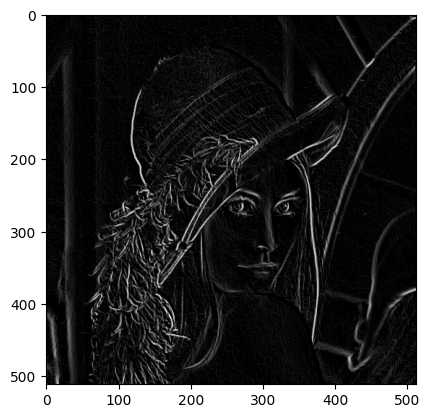

In [8]:
img_prewittx = cv.filter2D(gray_image, -1, kernelx)
img_prewitty = cv.filter2D(gray_image, -1, kernely)

prewitt = np.hypot(img_prewittx, img_prewitty) #square root of the sum of squares of the two images
prewitt = prewitt[:,:] #to convert the image from 3 channels to 1 channel
prewitt = prewitt.astype("int") #to convert the image to uint
plt.imshow(prewitt, cmap='gray')

# Sobel Filter

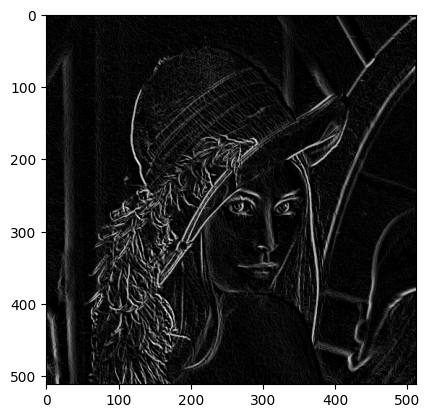

In [9]:
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
kernelx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])
kernely = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
    ])
img_sobelx = cv.filter2D(gray, -1, kernelx)
img_sobely = cv.filter2D(gray, -1, kernely)
sobel = np.hypot(img_sobelx, img_sobely) #square root of the sum of squares of the two images
sobel = sobel[:,:] #to convert the image from 3 channels to 1 channel
sobel = sobel.astype("int") #to convert the image to uint   
plt.imshow(sobel, cmap='gray')


# Canny edges

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

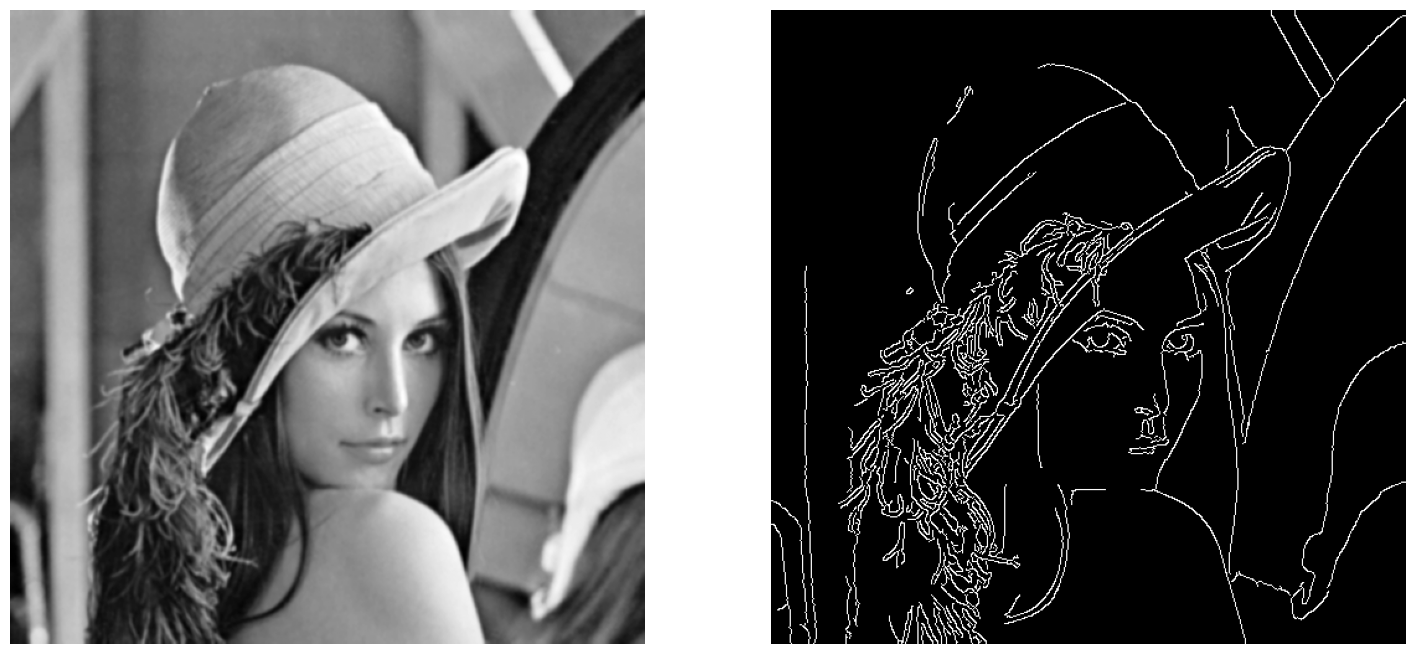

In [12]:
image = img
(H, W)= image.shape[:2] #(height, width, channel) so we take the first two values
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
blurred = cv.GaussianBlur(gray, (5, 5), 0)
canny = cv.Canny(blurred, 50, 150)
fig, ax = plt.subplots(1,2, figsize=(18,18))
ax[0].imshow(blurred, cmap='gray')
ax[1].imshow(canny, cmap='gray')
ax[0].axis('off')
ax[1].axis('off')